# AuraSync — ML Progress Report
**TECHIN 515 Team 6** · Indoor Air Quality Monitoring + Automatic Fragrance System

---

## System Overview
- **Hardware**: Seeed XIAO ESP32-S3 + Bosch BME680 sensor (bathroom deployment)
- **Data**: Temperature, Humidity, Pressure, Gas Resistance — sampled every 10 seconds → Firebase
- **ML Tasks**:
  1. **Indoor Air Quality (IAQ) Classification** — Good / Moderate / Poor
  2. **Shower Event Detection** — binary, for triggering automatic fragrance spray

---

In [1]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

# Paths (run from project root)
ROOT      = os.path.abspath('.')
PROC_DIR  = os.path.join(ROOT, 'Data', 'processed')
MODEL_DIR = os.path.join(ROOT, 'Data', 'models')
RAW_DIR   = os.path.join(ROOT, 'Data', 'raw')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Setup complete. ROOT =', ROOT)

Setup complete. ROOT = c:\Users\华硕\Desktop\TECHIN-515-Team6


---
## 1. Data Collection

In [2]:
all_feat = pd.read_csv(os.path.join(PROC_DIR, 'all_features.csv'), parse_dates=['datetime_utc'])

# Session summary
from zoneinfo import ZoneInfo
PDT = ZoneInfo('America/Los_Angeles')
all_feat['datetime_local'] = all_feat['datetime_utc'].apply(
    lambda x: x.tz_convert(PDT)
)

session_summary = (
    all_feat.groupby('session_id')
    .agg(
        readings    = ('datetime_utc', 'count'),
        duration_min= ('elapsed_s', lambda x: round(x.max() / 60, 1)),
        start_local = ('datetime_local', 'min'),
        split       = ('split', 'first')
    )
    .reset_index()
    .sort_values('start_local')
)
session_summary['start_local'] = session_summary['start_local'].dt.strftime('%m/%d %H:%M')

print(f'Total sessions : {len(session_summary)}')
print(f'Total readings : {len(all_feat):,}')
print(f'Collection span: {all_feat["datetime_local"].min().strftime("%Y-%m-%d")} → '
      f'{all_feat["datetime_local"].max().strftime("%Y-%m-%d")} (Seattle time)')
print()
display(session_summary[['session_id','start_local','readings','duration_min','split']])

Total sessions : 10
Total readings : 16,927
Collection span: 2026-04-29 → 2026-05-02 (Seattle time)



,session_id,start_local,readings,duration_min,split
1,20260429-192359,04/29 12:31,1788,305.2,train
0,19200530-065424,04/29 20:19,47,14.8,test
2,20260430-035330,04/29 21:00,1461,262.6,val
3,20260430-164104,04/30 09:48,1176,209.9,train
4,20260430-235226,04/30 16:59,5999,1014.5,test
5,20260501-164852,05/01 09:55,1104,203.5,train
6,20260501-204738,05/01 13:54,178,37.0,train
7,20260501-215415,05/01 15:01,48,15.4,train
8,20260502-025019,05/01 19:57,1867,330.1,train
9,20260502-082315,05/02 01:30,3259,551.6,train


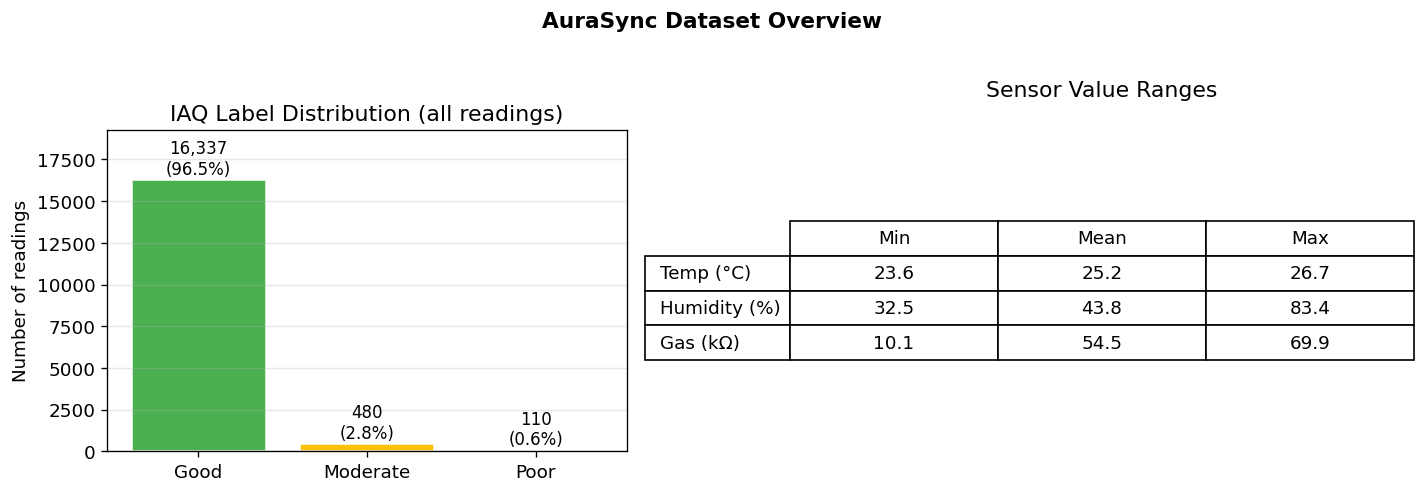

In [3]:
# IAQ label distribution
label_counts = all_feat['iaq_label'].value_counts().reindex(['Good','Moderate','Poor'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4CAF50', '#FFC107', '#F44336']
bars = ax1.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}\n({val/len(all_feat)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax1.set_title('IAQ Label Distribution (all readings)')
ax1.set_ylabel('Number of readings')
ax1.set_ylim(0, label_counts.max() * 1.18)
ax1.grid(axis='y', alpha=0.3)

# Sensor ranges
metrics = {'Temp (°C)': 'temp_c', 'Humidity (%)': 'humidity_pct', 'Gas (kΩ)': 'gas_ohm'}
stats = {}
for label, col in metrics.items():
    vals = all_feat[col]
    if col == 'gas_ohm':
        vals = vals / 1000
    stats[label] = {'min': vals.min(), 'mean': vals.mean(), 'max': vals.max()}
stats_df = pd.DataFrame(stats).T.round(1)

ax2.axis('off')
tbl = ax2.table(
    cellText=stats_df.values,
    rowLabels=stats_df.index,
    colLabels=['Min', 'Mean', 'Max'],
    cellLoc='center', loc='center'
)
tbl.scale(1.2, 2.0)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
ax2.set_title('Sensor Value Ranges', pad=20)

plt.suptitle('AuraSync Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Feature Engineering

Raw `gas_ohm` values cannot be used directly for ML — the sensor baseline drifted from ~50 kΩ to ~30 kΩ after exposure to strong VOC (air freshener). We apply **sliding-window baseline normalization**:

$$\text{gas\_norm}_t = \frac{\text{gas\_ohm}_t - \text{baseline}_t}{\text{baseline}_t}, \quad \text{baseline}_t = \max(\text{gas\_ohm}_{t-120:t})$$

- **Baseline window**: 20 minutes (120 samples) — long enough to survive a shower event  
- **Rolling max** (not mean): captures the most recent clean-air reference  
- **Result**: `gas_norm ≈ 0` = clean air, `gas_norm < -0.15` = degraded air quality

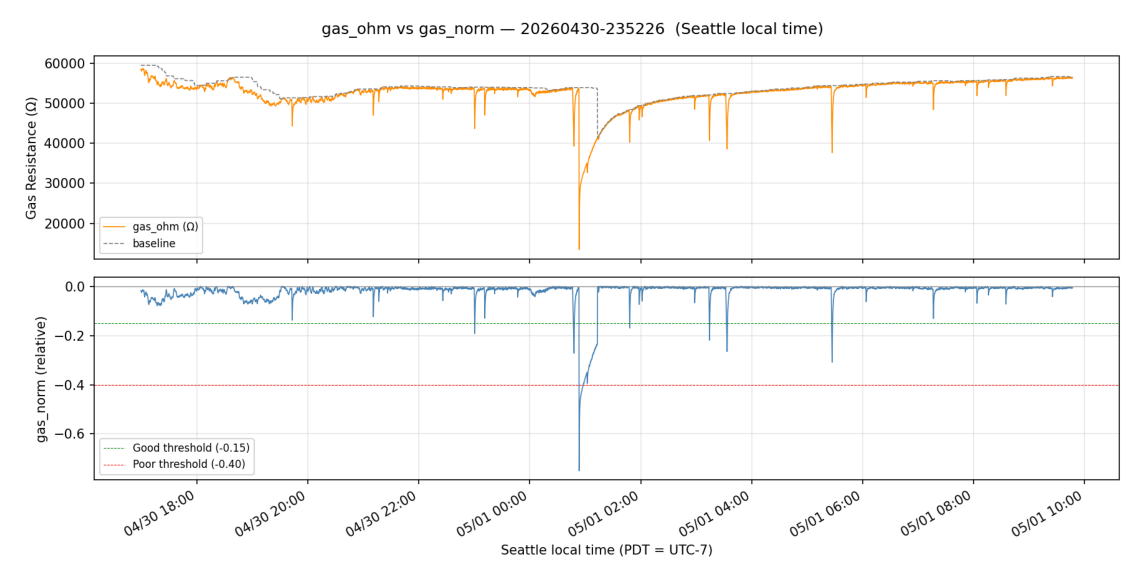

Session: 20260430-235226  (5,999 stable readings)


In [4]:
# Show gas_norm diagnostic for the longest session
longest_sid = all_feat.groupby('session_id').size().idxmax()
img_path = os.path.join(PROC_DIR, f'{longest_sid}_gas_norm.png')

if os.path.exists(img_path):
    img = mpimg.imread(img_path)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Session: {longest_sid}  ({all_feat[all_feat.session_id==longest_sid].shape[0]:,} stable readings)')

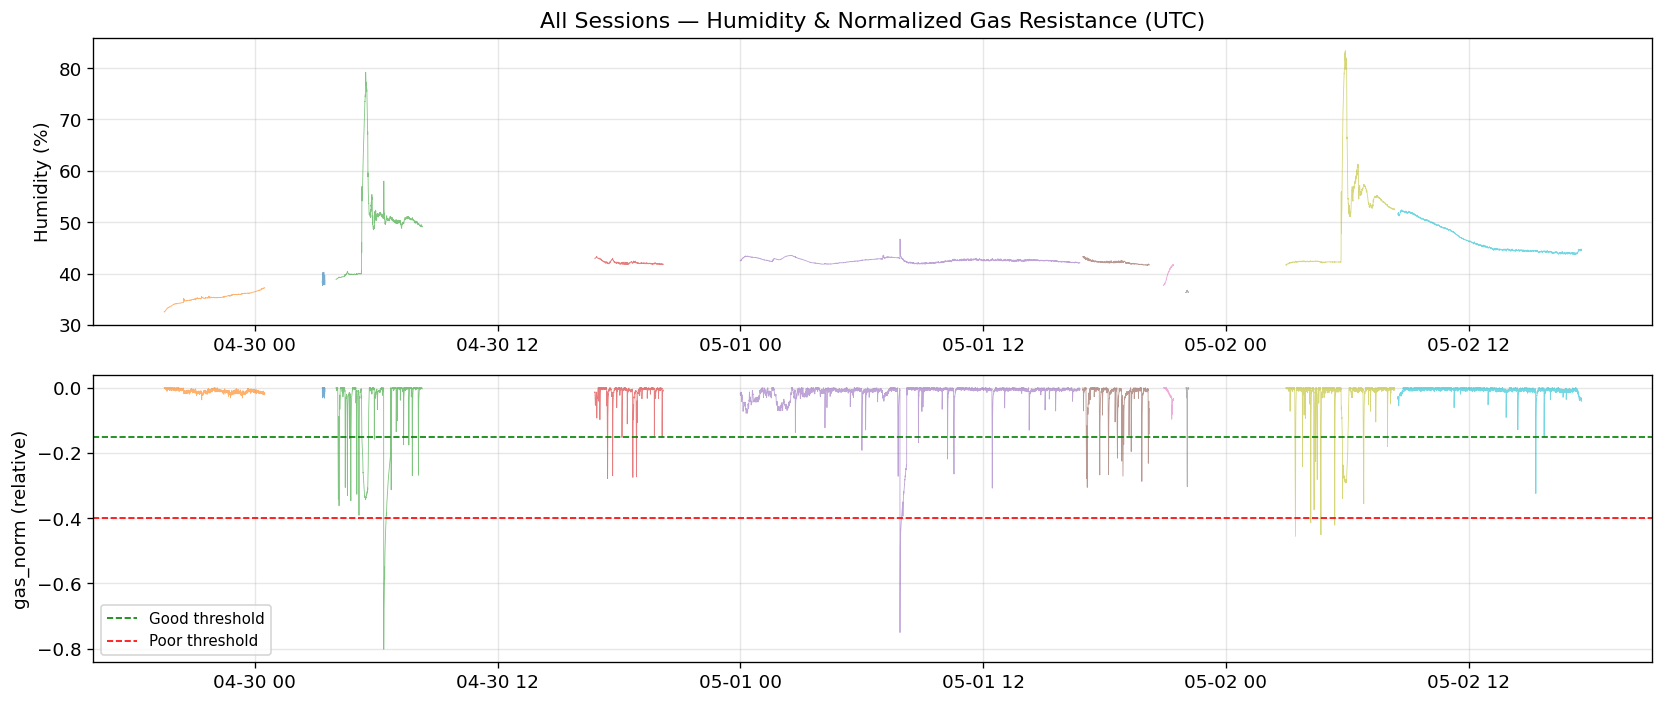

In [5]:
# gas_norm over time for all sessions (combined)
from zoneinfo import ZoneInfo

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for sid, grp in all_feat.groupby('session_id'):
    t = pd.to_datetime(grp['datetime_utc'], utc=True)
    axes[0].plot(t, grp['humidity_pct'], lw=0.5, alpha=0.6)
    axes[1].plot(t, grp['gas_norm'],     lw=0.5, alpha=0.6)

axes[0].set_ylabel('Humidity (%)')
axes[0].set_title('All Sessions — Humidity & Normalized Gas Resistance (UTC)')
axes[0].grid(alpha=0.3)

axes[1].axhline(-0.15, color='green', lw=1, ls='--', label='Good threshold')
axes[1].axhline(-0.40, color='red',   lw=1, ls='--', label='Poor threshold')
axes[1].set_ylabel('gas_norm (relative)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Features used for ML:**

| Feature | Description |
|---|---|
| `temp_c` | Raw temperature (°C) |
| `humidity_pct` | Raw humidity (%) |
| `gas_norm` | Normalized gas resistance (baseline-relative) |
| `humidity_delta_5m` | 5-minute rate of change of humidity |
| `temp_delta_5m` | 5-minute rate of change of temperature |
| `gas_delta_5m` | 5-minute rate of change of gas_norm |

---
## 3. Task 1 — Indoor Air Quality Classification

**Labels** are assigned by rule (BME680 datasheet + observed baseline):
- **Good**: `gas_norm > -0.15` AND `humidity < 65%` AND `temp < 27°C`
- **Poor**: `gas_norm < -0.40` OR `humidity > 80%`
- **Moderate**: everything else

**Model**: Random Forest (`n_estimators=200`, `class_weight='balanced'`)

In [6]:
# Load IAQ model and data
from sklearn.ensemble import RandomForestClassifier

iaq_payload = joblib.load(os.path.join(MODEL_DIR, 'iaq_rf_v1.pkl'))
model_rf    = iaq_payload['model']
le          = iaq_payload['label_encoder']
feat_cols   = iaq_payload['features']

iaq_df = pd.read_csv(os.path.join(PROC_DIR, 'iaq_features.csv')).dropna(subset=feat_cols)

CLASSES = ['Good', 'Moderate', 'Poor']
iaq_df['label_enc'] = LabelEncoder().fit(CLASSES).transform(iaq_df['iaq_label'])

print(f'IAQ dataset: {len(iaq_df):,} readings  |  {iaq_df.session_id.nunique()} sessions')
print('Label distribution:')
print(iaq_df['iaq_label'].value_counts().to_string())

IAQ dataset: 16,547 readings  |  10 sessions
Label distribution:
iaq_label
Good        15964
Moderate      473
Poor          110


In [7]:
# 5-fold GroupKFold cross-validation
X_all = iaq_df[feat_cols].values
y_all = iaq_df['label_enc'].values
groups = iaq_df['session_id'].values
all_labels = list(range(len(CLASSES)))

gkf = GroupKFold(n_splits=5)
fold_f1s = []
for fold, (tr, va) in enumerate(gkf.split(X_all, y_all, groups)):
    rf_fold = RandomForestClassifier(n_estimators=200, max_depth=10,
                                     min_samples_leaf=5, class_weight='balanced',
                                     random_state=42, n_jobs=-1)
    rf_fold.fit(X_all[tr], y_all[tr])
    f1 = f1_score(y_all[va], rf_fold.predict(X_all[va]),
                  average='macro', labels=all_labels, zero_division=0)
    fold_f1s.append(f1)
    print(f'  Fold {fold+1}: Macro F1 = {f1:.4f}')

print(f'\n  Mean ± Std: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}')

  Fold 1: Macro F1 = 1.0000
  Fold 2: Macro F1 = 0.5832
  Fold 3: Macro F1 = 0.6688
  Fold 4: Macro F1 = 0.6667
  Fold 5: Macro F1 = 0.9364

  Mean ± Std: 0.7710 ± 0.1652


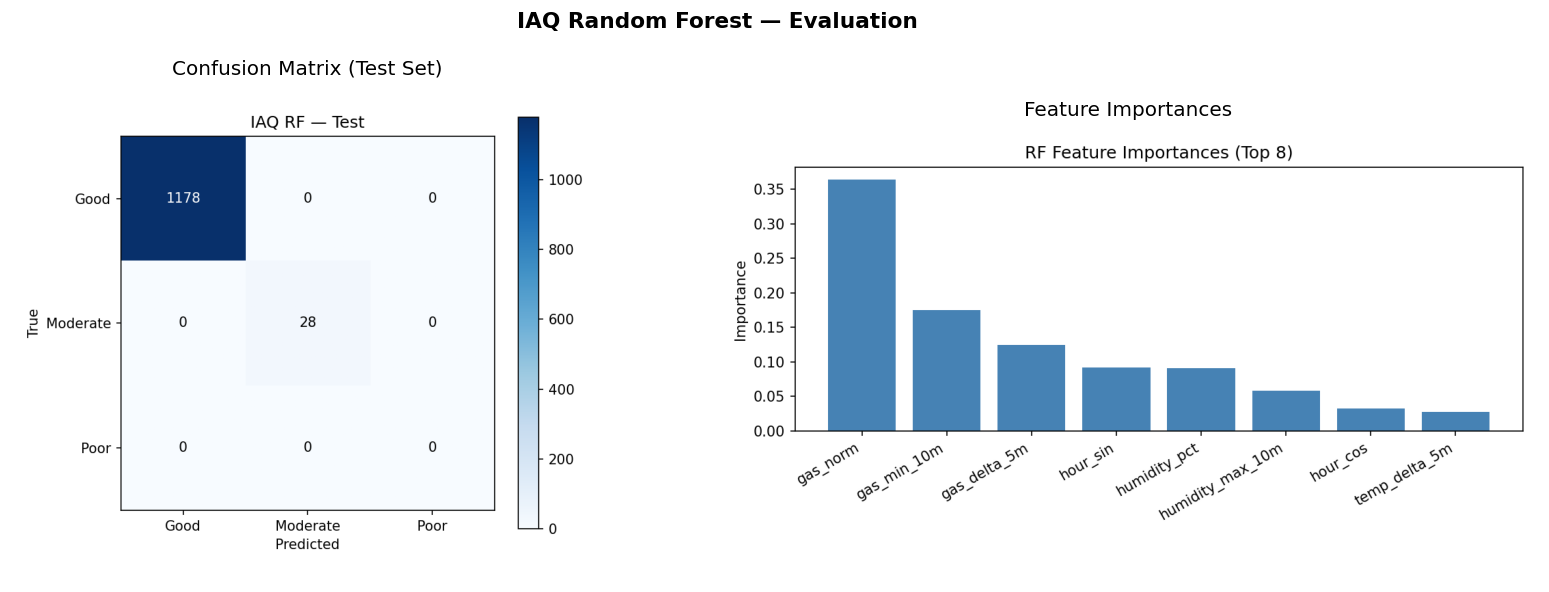

In [8]:
# Display saved confusion matrix and feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fname, title in zip(
    axes,
    ['iaq_rf_confusion.png', 'iaq_rf_features.png'],
    ['Confusion Matrix (Test Set)', 'Feature Importances']
):
    img = mpimg.imread(os.path.join(MODEL_DIR, fname))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=8)

plt.suptitle('IAQ Random Forest — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Summary table
results = json.load(open(os.path.join(MODEL_DIR, 'results.json')))
iaq_r   = results.get('iaq', {})

summary = pd.DataFrame({
    'Metric': ['CV Macro F1 (5-fold)', 'RF Val Macro F1', 'RF Test Macro F1', 'MLP Val Macro F1'],
    'Value':  [
        f'{np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}',
        f'{iaq_r.get("rf_val_macro_f1", "N/A")}',
        f'{iaq_r.get("rf_test_macro_f1", "N/A")}',
        f'{iaq_r.get("mlp_val_macro_f1", "N/A")}'
    ]
})
display(summary.style.set_caption('IAQ Classification — Results Summary').hide(axis='index'))

Metric,Value
CV Macro F1 (5-fold),0.7710 ± 0.1652
RF Val Macro F1,0.3333
RF Test Macro F1,0.6667
MLP Val Macro F1,0.3333


### Key observations
- **gas_norm** and **humidity_pct** are the top-2 predictors — consistent with domain knowledge
- **Macro F1 = 0.77 ± 0.17** (5-fold GroupKFold CV); variance is due to rare "Poor" samples missing in some val folds
- Class imbalance (96% Good) is handled by `class_weight='balanced'`

---
## 4. Task 2 — Shower Event Detection

**Approach**: Sliding-window binary classification (window = 5 min / 30 readings, stride = 50 s)  
**Model**: 1D-CNN with two convolutional layers (PyTorch, GPU-accelerated)  
**Training data**: 2 annotated shower sessions + 4× data augmentation (Gaussian jitter + magnitude scaling)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Load windows
X_train = np.load(os.path.join(PROC_DIR, 'shower_train_X.npy'))
y_train = np.load(os.path.join(PROC_DIR, 'shower_train_y.npy'))
X_val   = np.load(os.path.join(PROC_DIR, 'shower_val_X.npy'))
y_val   = np.load(os.path.join(PROC_DIR, 'shower_val_y.npy'))

print('Window shape (samples, timesteps, features):')
print(f'  Train: {X_train.shape}  |  shower={int(y_train.sum())}  non-shower={int((y_train==0).sum())}')
print(f'  Val:   {X_val.shape}    |  shower={int(y_val.sum())}   non-shower={int((y_val==0).sum())}')
print(f'\nDevice: {"CUDA (" + torch.cuda.get_device_name(0) + ")" if torch.cuda.is_available() else "CPU"}')

Window shape (samples, timesteps, features):
  Train: (1831, 30, 6)  |  shower=96  non-shower=1735
  Val:   (285, 30, 6)    |  shower=115   non-shower=170

Device: CUDA (NVIDIA GeForce RTX 4060 Laptop GPU)


In [11]:
# Load trained CNN and run inference on val set
ckpt = torch.load(os.path.join(MODEL_DIR, 'shower_cnn_v1.pt'), map_location='cpu')
N_FEAT   = ckpt['n_features']
WIN_SIZE = ckpt['window_size']
THRESHOLD = ckpt['threshold']

class ShowerCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(N_FEAT, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.AdaptiveAvgPool1d(8)
        self.fc1   = nn.Linear(64 * 8, 32)
        self.fc2   = nn.Linear(32, 1)
        self.drop  = nn.Dropout(0.3)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).flatten(1)
        return self.fc2(F.relu(self.fc1(self.drop(x)))).squeeze(-1)

model = ShowerCNN()
model.load_state_dict(ckpt['state_dict'])
model.eval()

with torch.no_grad():
    logits = model(torch.from_numpy(X_val.astype(np.float32))).numpy()

probs  = 1 / (1 + np.exp(-logits))
preds  = (probs >= THRESHOLD).astype(int)
y_true = y_val.astype(int)

val_f1 = f1_score(y_true, preds)
print(f'Val F1 @ threshold={THRESHOLD:.2f}: {val_f1:.4f}')
print()
print(classification_report(y_true, preds, target_names=['No Shower', 'Shower']))

Val F1 @ threshold=0.70: 0.7684

              precision    recall  f1-score   support

   No Shower       0.80      0.99      0.88       170
      Shower       0.97      0.63      0.77       115

    accuracy                           0.85       285
   macro avg       0.89      0.81      0.83       285
weighted avg       0.87      0.85      0.84       285



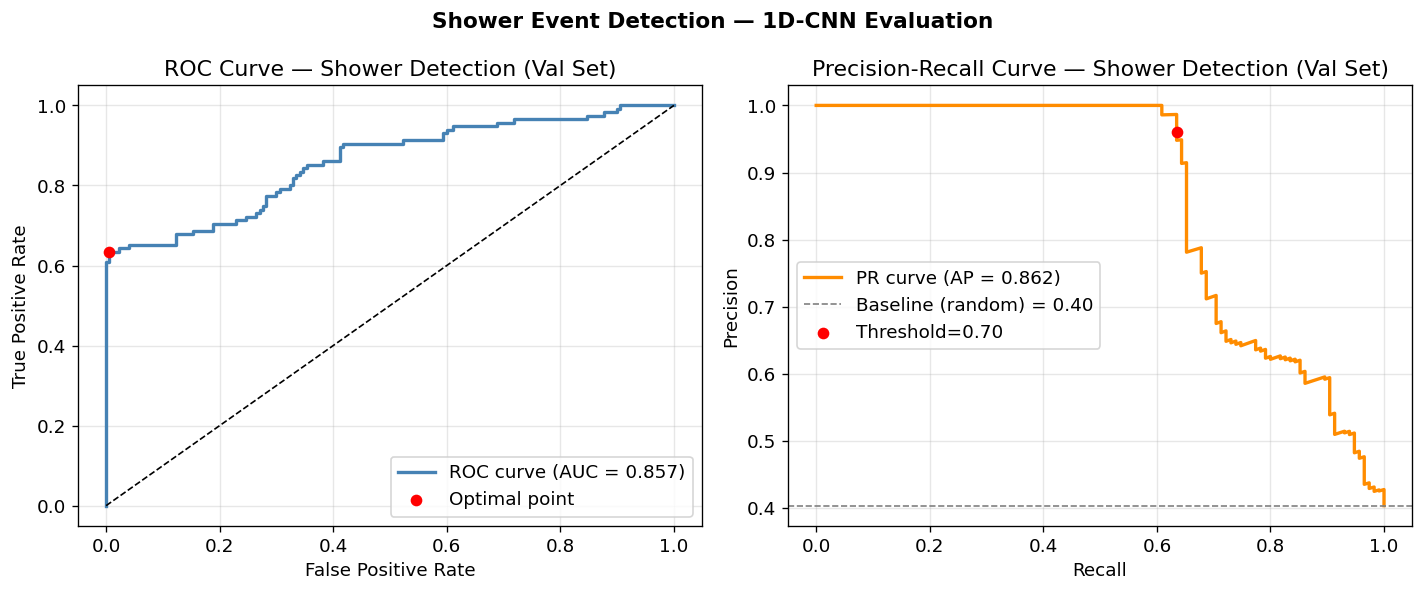

In [12]:
# ROC curve + Precision-Recall curve
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc      = auc(fpr, tpr)

precision, recall, thresholds_pr = precision_recall_curve(y_true, probs)
ap = average_precision_score(y_true, probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.scatter(fpr[np.argmax(tpr - fpr)], tpr[np.argmax(tpr - fpr)],
            color='red', zorder=5, label='Optimal point')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Shower Detection (Val Set)')
ax1.legend()
ax1.grid(alpha=0.3)

# PR curve
ax2.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AP = {ap:.3f})')
baseline = y_true.mean()
ax2.axhline(baseline, color='gray', ls='--', lw=1, label=f'Baseline (random) = {baseline:.2f}')
# Mark operating point
op_idx = np.argmin(np.abs(thresholds_pr - THRESHOLD))
ax2.scatter(recall[op_idx], precision[op_idx],
            color='red', zorder=5, label=f'Threshold={THRESHOLD:.2f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — Shower Detection (Val Set)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Shower Event Detection — 1D-CNN Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

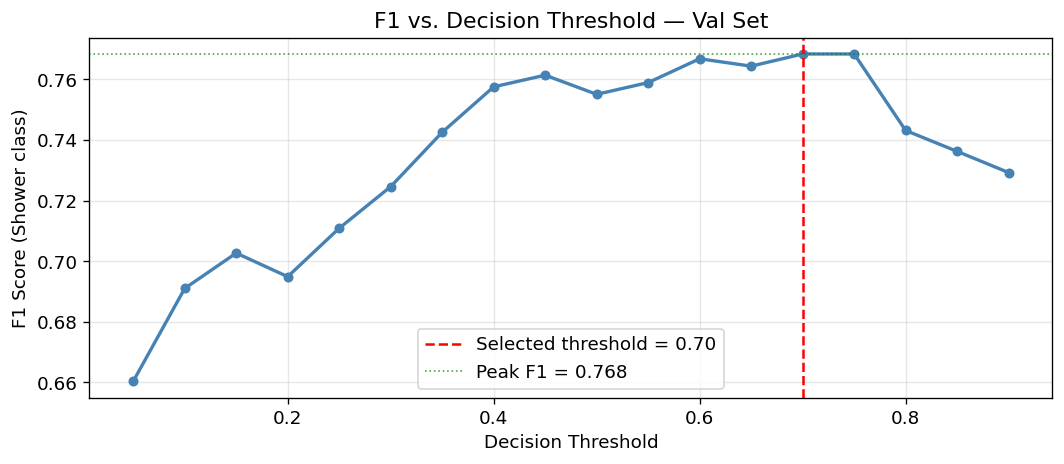

Best threshold: 0.70  →  F1 = 0.7684


In [13]:
# Threshold sweep — show F1 vs threshold
thresholds = np.arange(0.05, 0.95, 0.05)
f1_scores  = [f1_score(y_true, (probs >= t).astype(int), zero_division=0) for t in thresholds]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, 'o-', color='steelblue', lw=2, markersize=5)
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Selected threshold = {THRESHOLD:.2f}')
ax.axhline(max(f1_scores), color='green', ls=':', lw=1, alpha=0.7, label=f'Peak F1 = {max(f1_scores):.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score (Shower class)')
ax.set_title('F1 vs. Decision Threshold — Val Set')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best threshold: {thresholds[np.argmax(f1_scores)]:.2f}  →  F1 = {max(f1_scores):.4f}')

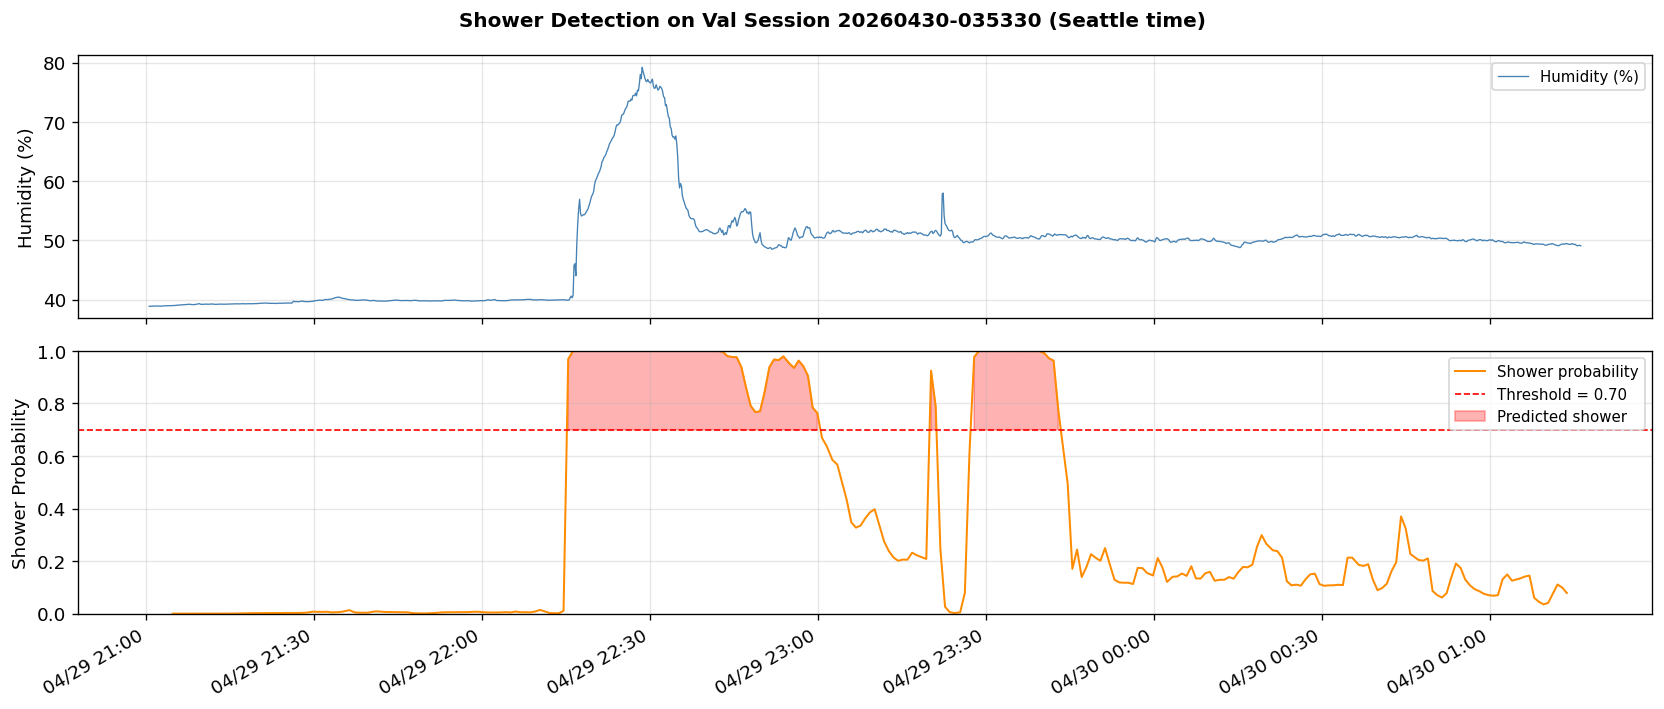

In [14]:
# Visualize predicted probabilities on the val session timeline
val_session_id = '20260430-035330'  # the annotated val session
from zoneinfo import ZoneInfo
PDT = ZoneInfo('America/Los_Angeles')

sess_df = all_feat[all_feat['session_id'] == val_session_id].copy()
sess_df['datetime_local'] = sess_df['datetime_utc'].apply(lambda x: x.tz_convert(PDT))

WINDOW_SIZE, STRIDE = 30, 5
FEATURE_COLS = ['temp_c', 'humidity_pct', 'gas_norm',
                'humidity_delta_5m', 'temp_delta_5m', 'gas_delta_5m']

# Load the scaler used during preprocessing
with open(os.path.join(PROC_DIR, 'scalers.pkl'), 'rb') as f:
    scalers = pickle.load(f)
scaler = scalers['window_scaler']

# Build windows for this session
arr = sess_df[FEATURE_COLS].values.astype(np.float32)
times_mid, prob_list = [], []

for i in range(0, len(arr) - WINDOW_SIZE + 1, STRIDE):
    window = arr[i : i + WINDOW_SIZE]
    if np.isnan(window).any():
        continue
    window_scaled = scaler.transform(window).reshape(1, WINDOW_SIZE, len(FEATURE_COLS))
    with torch.no_grad():
        logit = model(torch.from_numpy(window_scaled)).item()
    times_mid.append(sess_df['datetime_local'].iloc[i + WINDOW_SIZE // 2])
    prob_list.append(1 / (1 + np.exp(-logit)))

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(sess_df['datetime_local'], sess_df['humidity_pct'],
         color='steelblue', lw=0.8, label='Humidity (%)')
ax1.set_ylabel('Humidity (%)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(times_mid, prob_list, color='darkorange', lw=1.2, label='Shower probability')
ax2.axhline(THRESHOLD, color='red', ls='--', lw=1, label=f'Threshold = {THRESHOLD:.2f}')
ax2.fill_between(times_mid, prob_list, THRESHOLD,
                 where=[p >= THRESHOLD for p in prob_list],
                 alpha=0.3, color='red', label='Predicted shower')
ax2.set_ylabel('Shower Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

import matplotlib.dates as mdates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M', tz=PDT))
plt.xticks(rotation=30, ha='right')
plt.suptitle(f'Shower Detection on Val Session {val_session_id} (Seattle time)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Results Summary

| Task | Model | Key Metric | Value | Status |
|---|---|---|---|---|
| IAQ Classification | Random Forest | 5-fold GroupKFold CV Macro F1 | **0.77 ± 0.17** | ✅ Functional |
| Shower Detection | 1D-CNN (PyTorch, GPU) | Val F1 @ threshold=0.70 | **0.77** | ⚠️ Limited by training data |

> **Note**: IAQ single-split val F1 = 0.33 because the val fold had no "Poor" samples — CV F1 is the reliable estimate.

---
## 6. Limitations

- Shower model trained on only **2 annotated sessions** → 96 real positive windows (+ 4× augmentation)
- No shower labels in test set — val F1 used as generalization proxy
- IAQ labels are **rule-based** (manual thresholds on gas_norm + humidity + temp), not ground-truth IAQ measurements
- Model trained on one bathroom — generalizability requires per-device calibration for different environments

---
## 7. Firmware Upgrade — Bosch BSEC2 Integration

### Problem with the current approach
The raw `gas_ohm` baseline drifted permanently from **~50 kΩ → ~30 kΩ** after exposure to a strong activator, then slowly recovered. Our manual 20-minute rolling-max baseline cannot handle multi-day drift — it only captures short-term changes.

### Solution: Replace manual normalization with Bosch BSEC2
The firmware (`Code/VOCLogger/src/main.cpp`) was upgraded to use the **Bosch BSEC2 library** (v1.10.x, ESP32-S3 compatible) instead of the Adafruit BME680 driver. BSEC2 is Bosch’s official algorithm that:
- Performs **self-calibrating baseline** estimation (short-term + long-term, up to weeks)
- Outputs a standardized **IAQ index (0–500)** — same scale across all BME680 units
- Applies **heat-source compensation** to temperature and humidity (corrects chip self-heating)
- Persists calibration state to ESP32 NVS (survives reboots)

### Library version: BSEC2 Standard (free)
We use the free **BSEC2 Standard** library. The Extended/Professional version (paid) provides additional derived outputs that are not available to us:

| Field | Available? | Note |
|---|---|---|
| `iaq` | ✅ Yes | Calibrated IAQ index 0–500 |
| `iaq_accuracy` | ✅ Yes | 0=unreliable → 3=fully calibrated |
| `gas_ohm` | ✅ Yes | Raw gas resistance (core VOC signal) |
| `temp_c` | ✅ Yes | Heat-source compensated |
| `humidity_pct` | ✅ Yes | Heat-source compensated |
| `pressure_hpa` | ✅ Yes | Raw barometric pressure |
| `static_iaq` | ❌ Not available | BSEC2 Extended only |
| `co2_eq_ppm` | ❌ Not available | BSEC2 Extended only |
| `breath_voc_ppm` | ❌ Not available | BSEC2 Extended only |

**Impact on ML pipeline:** Minimal. `gas_ohm` (the core VOC signal) and `iaq` (calibrated score) are both available. The three missing fields are all *derived* from `gas_ohm` + temperature + humidity — they add no independent information beyond what we already have.

### Impact on IAQ generalizability
Because BSEC2 self-calibrates per device, `iaq` is relative to that sensor’s own learned baseline. This makes IAQ **comparable across different environments** — solving the sensor-to-sensor variation problem inherent to raw gas resistance values.

### Calibration timeline
| iaq_accuracy | Meaning | Expected after |
|---|---|---|
| 0 | Unreliable — exclude from training | First ~30 min |
| 1 | Low accuracy — relative changes valid | ~30 min |
| 2 | Medium accuracy | ~1–2 days |
| 3 | Fully calibrated | ~4 days continuous |

Filter when training: `df = df[df['iaq_accuracy'] >= 1]`

---
## 8. Next Week Plan — Data Collection + Extreme Case Testing

### Phase 1: Day 0–1 — Flash BSEC firmware, start calibration
- Flash updated firmware; confirm `iaq_accuracy` field appears in Firebase
- Sensor stays powered continuously in bathroom (NVS preserves calibration across reboots)

### Phase 2: Day 1–4 — Shower data collection
Record **5+ annotated shower sessions**. For each shower:
1. Note local start/end time (e.g. 22:35 – 23:05 Seattle)
2. Convert to UTC (+7h): 05:35Z – 06:05Z
3. Append to `Data/shower_annotations.csv`, then re-run:
```
python Code/ml/preprocess.py
python Code/ml/train_shower.py    # target: val F1 ≥ 0.85
```
No extreme tests during this phase — keep environment stable for BSEC calibration.

---

### Phase 3: Day 4–7 — Extreme Case Testing (iaq_accuracy ≥ 2)

Record **local time + test description** for each event to cross-reference with sensor curves afterward.

#### Group 1 — VOC Stimulus Tests (IAQ response)

| Test | Procedure | Expected Response |
|---|---|---|
| **Perfume** | Spray 2–3 times in closed bathroom | `static_iaq` spikes within 1–2 min, recovers in 30–60 min |
| **Air freshener** | Spray Febreze / Glade, close door | Similar to perfume, potentially longer tail |
| **Bathroom cleaner** | Spray bleach-based cleaner, open window after 5 min | Large IAQ spike (Cl-type VOCs); tests sensor range |
| **Baseline (control)** | Leave bathroom unused, door closed, 2 hrs | `static_iaq` should stay in low range — confirms clean-air floor |

#### Group 2 — Shower Edge Cases (detection robustness)

| Test | Procedure | What We're Verifying |
|---|---|---|
| **Short shower** | Shower for only 3–4 min | Can 5-min window still detect it? |
| **Long shower** | Shower for 25–30 min | Is detection stable across the full duration? |
| **Hot water only, no person** | Run hot water 10 min, bathroom empty | Does steam alone trigger a false positive? |
| **Shower + spray** | Spray air freshener immediately after showering | Compound event — does detection hold? |
| **High-humidity day** | Normal activity on a rainy/humid day | Does elevated baseline humidity cause false positives? |

#### Group 3 — Device Stress Tests

| Test | Procedure | Purpose |
|---|---|---|
| **Power cycle** | Unplug and replug ESP32 | Verify BSEC calibration reloads from NVS correctly |
| **Strong VOC shock** | Spray strong activator (same type as the previous incident) | Verify BSEC recovers gracefully; check `iaq_accuracy` dip and recovery |
| **Extended seal** | Close bathroom, no activity, 4 hours | Observe natural CO₂/VOC accumulation curve |

---

### Recording Template (fill for each test)

```
Date       | Local time     | Test             | Duration | Ventilation | Notes
-----------+----------------+------------------+----------+-------------+--------
2026-05-07 | 21:30 – 21:45  | Perfume (3 sprays) | 15 min  | Door closed |
```

After each test, check the `static_iaq` timeline in the notebook's Section 4 visualization to confirm the sensor responded as expected.